In [1]:
# 导入必要的库
import matplotlib as mpl
import matplotlib.pyplot as plt
# 在Jupyter notebook中内联显示图表
%matplotlib inline
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
from tqdm.auto import tqdm  # 进度条库
import torch
import torch.nn as nn
import torch.nn.functional as F

# 打印Python版本信息
print(sys.version_info)

# 打印各个库的版本信息
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)

# 设置设备：如果有GPU则使用GPU，否则使用CPU
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)


sys.version_info(major=3, minor=12, micro=12, releaselevel='final', serial=0)
matplotlib 3.10.0
numpy 2.0.2
pandas 2.2.2
sklearn 1.6.1
torch 2.9.0+cu126
cuda:0


In [2]:
import json
token = {"username":"cskaoyan","key":"ff99d9d7ff71704e3e761217ceec03c5"}
with open('/content/kaggle.json', 'w') as file:
  json.dump(token, file)

In [3]:
!cat /content/kaggle.json

{"username": "cskaoyan", "key": "ff99d9d7ff71704e3e761217ceec03c5"}

In [4]:
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle config set -n path -v /content

- path is now set to: /content


In [5]:
!kaggle competitions download -c cifar-10

 96% 688M/715M [00:04<00:00, 164MB/s]
100% 715M/715M [00:04<00:00, 182MB/s]


In [6]:
!unzip /content/competitions/cifar-10/cifar-10.zip

Archive:  /content/competitions/cifar-10/cifar-10.zip
  inflating: sampleSubmission.csv    
  inflating: test.7z                 
  inflating: train.7z                
  inflating: trainLabels.csv         


In [7]:
%pip install py7zr
import py7zr
a =py7zr.SevenZipFile(r'./train.7z','r')
a.extractall(path=r'./competitions/cifar-10/')
a.close()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.4/71.4 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.2/494.2 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.6/100.6 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 16.6 MB/s eta 0:00:00


In [8]:
!cp sampleSubmission.csv trainLabels.csv /content/competitions/cifar-10

In [9]:
!ls /content/competitions/cifar-10/

cifar-10.zip  sampleSubmission.csv  train  trainLabels.csv


In [10]:
# import py7zr
# b = py7zr.SevenZipFile(r'./test.7z', 'r')
# a.extractall(path=r'./competitions/cifar-10/')
# b.close()

# 数据预处理

In [11]:
from pathlib import Path

DATA_DIR = Path("/content/competitions/cifar-10")

train_lables_file = DATA_DIR / "trainLabels.csv"
test_csv_file = DATA_DIR / "sampleSubmission.csv" #测试集模板csv文件
train_folder = DATA_DIR / "train"
test_folder = DATA_DIR / "test"


#所有的类别
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck',
]
# INSERT_YOUR_CODE
import pandas as pd

def load_image_paths_and_labels(labels_csv_path, images_folder):
    """
    读取labels_csv_path（trainLabels.csv），为每张图片拼接完整路径，并返回[(img_path, label), ...]的列表
    """
    df = pd.read_csv(labels_csv_path)
    items = []
    for idx, row in df.iterrows():
        img_name = row['id']  # 假设csv第一列是id（去掉.jpg后缀的文件名）
        label = row['label']
        img_path = images_folder / f"{img_name}.png"  # cifar10可能是png，也可能是jpg，请确保格式一致
        if not img_path.exists():
            img_path = images_folder / f"{img_name}.jpg"
        items.append( (str(img_path), label) )
    return items

# 示例调用方法
train_items = load_image_paths_and_labels(train_lables_file, train_folder)
# test_items = load_image_paths_and_labels(test_csv_file, test_folder)

import pprint
pprint.pprint(train_items[:5])



[('/content/competitions/cifar-10/train/1.png', 'frog'),
 ('/content/competitions/cifar-10/train/2.png', 'truck'),
 ('/content/competitions/cifar-10/train/3.png', 'truck'),
 ('/content/competitions/cifar-10/train/4.png', 'deer'),
 ('/content/competitions/cifar-10/train/5.png', 'automobile')]


In [12]:
# INSERT_YOUR_CODE
import pandas as pd

# 将train_items分为45000条用于训练，5000条用于验证
train_items_ = train_items[:45000]
valid_items_ = train_items[45000:]

# 转为DataFrame
train_df = pd.DataFrame(train_items_, columns=["img_path", "label"])
valid_df = pd.DataFrame(valid_items_, columns=["img_path", "label"])
# test_df = pd.DataFrame(test_items, columns=["img_path", "label"])


In [13]:
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class Cifar10Dataset(Dataset):
    df_map = {
        "train": train_df,
        "eval": valid_df,
    }
    label_to_idx = {label: idx for idx, label in enumerate(class_names)} # 类别映射为idx
    idx_to_label = {idx: label for idx, label in enumerate(class_names)} # idx映射为类别,为了test使用
    def __init__(self, mode, transform=None):
        self.df = self.df_map.get(mode, None) # 获取对应模式的df，不同字符串对应不同模式
        if self.df is None:
            raise ValueError("mode should be one of train, val, test, but got {}".format(mode))
        # assert self.df, "df is None"
        self.transform = transform

    def __getitem__(self, index):
        img_path, label = self.df.iloc[index] # 获取图片路径和标签
        img = Image.open(img_path).convert('RGB')
        # # img 转换为 channel first
        # img = img.transpose((2, 0, 1))
        # transform
        img = self.transform(img) # 数据增强
        # label 转换为 idx
        label = self.label_to_idx[label]
        return img, label

    def __len__(self):
        return self.df.shape[0] # 返回df的行数,样本数

IMAGE_SIZE = 32
mean, std = [0.4914, 0.4822, 0.4465], [0.247, 0.243, 0.261]

transforms_train = transforms.Compose([
        # resize
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)), #缩放
        # random rotation 40
        transforms.RandomRotation(40), #随机旋转
        # horizaontal flip
        transforms.RandomHorizontalFlip(),  #随机水平翻转
        transforms.ToTensor(), #转换为tensor
        transforms.Normalize(mean, std) #标准化
    ]) #数据增强

transforms_eval = transforms.Compose([
        # resize
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])
# ToTensor还将图像的维度从[height, width, channels]转换为[channels, height, width]。
train_ds = Cifar10Dataset("train", transforms_train)
eval_ds = Cifar10Dataset("eval", transforms_eval)

In [14]:

# 对train_ds计算均值和标准差
# from torch.utils.data import DataLoader
# import torch
#
# loader = DataLoader(train_ds, batch_size=64, shuffle=False, num_workers=2)
#
# mean = torch.zeros(3)
# std = torch.zeros(3)
# n_pixels = 0
#
# for images, _ in loader:  # images: [B, 3, H, W]
#     batch_pixels = images.shape[0] * images.shape[2] * images.shape[3]
#     mean += images.sum([0, 2, 3])
#     std += (images ** 2).sum([0, 2, 3])
#     n_pixels += batch_pixels
#
# mean /= n_pixels
# std = torch.sqrt(std / n_pixels - mean ** 2)
#
# print("train_ds按通道均值:", mean)
# print("train_ds按通道标准差:", std)



In [15]:
from torch.utils.data import DataLoader

# 创建训练集和验证集的DataLoader
batch_size = 32

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,  # 训练时打乱数据
)

test_loader = DataLoader(
    eval_ds,
    batch_size=batch_size,
    shuffle=False,  # 测试时不需要打乱
)

print(f"训练集DataLoader批次数: {len(train_loader)}")
print(f"测试集DataLoader批次数: {len(test_loader)}")
print(f"每个批次大小: {batch_size}")

# 查看一个批次的数据
for batch_images, batch_labels in train_loader:
    print(f"批次图像张量形状: {batch_images.shape}")
    print(f"批次标签张量形状: {batch_labels.shape}")
    print(batch_labels)
    break

训练集DataLoader批次数: 1407
测试集DataLoader批次数: 157
每个批次大小: 32
批次图像张量形状: torch.Size([32, 3, 32, 32])
批次标签张量形状: torch.Size([32])
tensor([1, 3, 9, 1, 1, 0, 5, 6, 5, 8, 3, 7, 3, 8, 3, 7, 3, 6, 6, 5, 0, 0, 3, 5,
        7, 5, 1, 8, 0, 5, 0, 6])


# 搭建模型

In [16]:
import torch.nn as nn
import torch

class VGG11(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            # 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),  # (64, 32, 32)
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),       # (64, 16, 16)

            # 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1), # (128, 16,16)
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),        # (128, 8,8)

            # 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1), # (256,8,8)
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), # (256,8,8)
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),        # (256,4,4)

            # 4
            nn.Conv2d(256, 512, kernel_size=3, padding=1), # (512,4,4)
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), # (512,4,4)
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),        # (512,2,2)

            # 5
            nn.Conv2d(512, 512, kernel_size=3, padding=1), # (512,2,2)
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), # (512,2,2)
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),        # (512,1,1)
        )
        # 给 classifier 一个独立的名字，且用 nn.ModuleDict 便于权重名称唯一
        self.classifier = nn.Sequential(
            nn.Flatten(),  # (batch, 512*1*1)
            nn.Linear(512, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, num_classes),
        )

        self._initialize_weights()

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
    @classmethod
    def from_pretrained1(cls, checkpoint_path, num_classes):
        """
        加载已经训练好的模型权重，并去掉最后一层全连接层，其余权重灌入模型
        checkpoint_path: 已有权重的文件路径
        num_classes: 新任务的类别数
        """
        import torch

        # 1. 实例化模型
        model = cls(num_classes=num_classes)

        # 2. 加载权重
        checkpoint = torch.load(checkpoint_path, map_location=device)
        if 'state_dict' in checkpoint:
            state_dict = checkpoint['state_dict']
        else:
            state_dict = checkpoint

        # 3. 获取除了最后一层全连接以外的权重
        # self.my_classifier[-1] 就是最后的 Linear 层
        # 遍历 state_dict，去掉 my_classifier.3.* （最后一层的参数）
        filtered_dict = {}
        for k, v in state_dict.items():
            # 剥离最后一个全连接层参数（假定为 my_classifier.3.weight/bias）
            if not (k.startswith('classifier.3') or k.startswith('classifier.3')):
                filtered_dict[k] = v

        # 4. 加载权重到新模型，strict=False 允许最后一层不匹配
        model.load_state_dict(filtered_dict, strict=False)
        return model

# 初始化模型
model = VGG11(num_classes=len(class_names))


In [17]:
128*16*16*256

8388608

In [18]:
# 使用随机输入对模型进行一次前向计算以验证模型结构是否正确
import torch

dummy_input = torch.randn(32, 3, 32, 32)
output = model(dummy_input) #前向传播/前向计算/正向传播
print(f"Output shape: {output.shape}")


Output shape: torch.Size([32, 10])


In [19]:
# 输出model每一层的参数量
total_params = 0  # 初始化总参数量为0
print("各层参数量统计：")  # 打印参数统计表头
for name, param in model.named_parameters():  # 遍历模型中所有需要优化的参数
    if param.requires_grad:  # 只有需要梯度更新的参数才统计
        num_params = param.numel()  # 计算当前参数的元素总数
        total_params += num_params  # 更新总参数量
        print(f"{name}: {num_params}")  # 输出当前层的参数量
print(f"模型总参数量: {total_params}")  # 输出模型总参数量


各层参数量统计：
features.0.weight: 1728
features.0.bias: 64
features.3.weight: 73728
features.3.bias: 128
features.6.weight: 294912
features.6.bias: 256
features.8.weight: 589824
features.8.bias: 256
features.11.weight: 1179648
features.11.bias: 512
features.13.weight: 2359296
features.13.bias: 512
features.16.weight: 2359296
features.16.bias: 512
features.18.weight: 2359296
features.18.bias: 512
classifier.1.weight: 262144
classifier.1.bias: 512
classifier.3.weight: 5120
classifier.3.bias: 10
模型总参数量: 9488266


# 训练

In [20]:
import torch.nn as nn
import torch.optim as optim

# 初始化交叉熵损失函数，内部会做softmax
criterion = nn.CrossEntropyLoss()

# 初始化优化器（这里选用Adam，也可以使用SGD等）
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [22]:
import wangdao_train


# 初始化模型保存对象
model_checkpoint = wangdao_train.ModelCheckpoint(
    filepath='./checkpoints/cifar10_model_epoch_{epoch}.ckpt',
    monitor='val_acc',
    save_best_only=True,
    mode='max',
    min_delta=0.001
)
# 假设train_loader和val_loader已定义，device已经设为"cuda"或"cpu"
trainer = wangdao_train.Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    eval_step=100,
    model_checkpoint=model_checkpoint
)

# 设定训练轮数
num_epochs = 10

# 开始训练
trainer.train(num_epochs)


[Step 100] Val Loss: 2.0973 Val Acc: 0.1690
[Step 200] Val Loss: 1.9633 Val Acc: 0.2376
[Step 300] Val Loss: 1.9495 Val Acc: 0.2426
[Step 400] Val Loss: 1.8082 Val Acc: 0.2746
[Step 500] Val Loss: 1.7807 Val Acc: 0.2686
[Step 600] Val Loss: 1.7271 Val Acc: 0.3480
[Step 700] Val Loss: 1.6870 Val Acc: 0.3456
[Step 800] Val Loss: 1.6360 Val Acc: 0.3792
[Step 900] Val Loss: 1.6655 Val Acc: 0.3576
[Step 1000] Val Loss: 1.5855 Val Acc: 0.4080
[Step 1100] Val Loss: 1.5651 Val Acc: 0.4156
[Step 1200] Val Loss: 1.5229 Val Acc: 0.4032
[Step 1300] Val Loss: 1.5474 Val Acc: 0.4176
[Step 1400] Val Loss: 1.5174 Val Acc: 0.4360
Epoch [1/10]  Train Loss: 1.7960  Train Acc: 0.3168
[Step 1500] Val Loss: 1.5188 Val Acc: 0.4264
[Step 1600] Val Loss: 1.4687 Val Acc: 0.4546
[Step 1700] Val Loss: 1.5043 Val Acc: 0.4506
[Step 1800] Val Loss: 1.4243 Val Acc: 0.4616
[Step 1900] Val Loss: 1.4158 Val Acc: 0.4714
[Step 2000] Val Loss: 1.4175 Val Acc: 0.4718
[Step 2100] Val Loss: 1.4657 Val Acc: 0.4674
[Step 2200] 

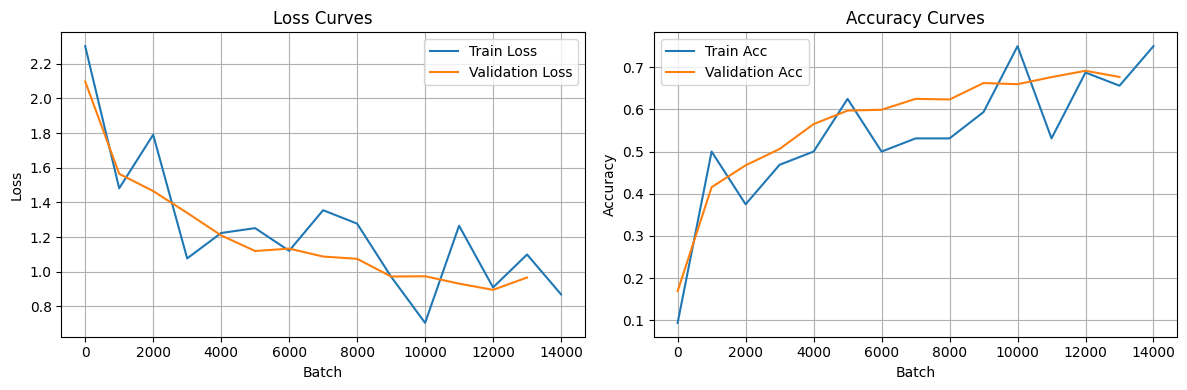

In [23]:
trainer.plot_curves()


[Step 100] Val Loss: 1.0241 Val Acc: 0.6986
[Step 200] Val Loss: 0.8863 Val Acc: 0.7114
[Step 300] Val Loss: 0.8522 Val Acc: 0.7142
[Step 400] Val Loss: 0.8377 Val Acc: 0.7144
[Step 500] Val Loss: 0.8236 Val Acc: 0.7168
[Step 600] Val Loss: 0.8187 Val Acc: 0.7206
[Step 700] Val Loss: 0.8133 Val Acc: 0.7210
[Step 800] Val Loss: 0.8133 Val Acc: 0.7212
[Step 900] Val Loss: 0.8034 Val Acc: 0.7240
[Step 1000] Val Loss: 0.8051 Val Acc: 0.7238
[Step 1100] Val Loss: 0.8022 Val Acc: 0.7248
[Step 1200] Val Loss: 0.7969 Val Acc: 0.7258
[Step 1300] Val Loss: 0.7969 Val Acc: 0.7284
[Step 1400] Val Loss: 0.7994 Val Acc: 0.7264
Epoch [1/10]  Train Loss: 0.9161  Train Acc: 0.6865
[Step 1500] Val Loss: 0.7967 Val Acc: 0.7246
[Step 1600] Val Loss: 0.7963 Val Acc: 0.7262
[Step 1700] Val Loss: 0.7908 Val Acc: 0.7264
[Step 1800] Val Loss: 0.7884 Val Acc: 0.7304
[Step 1900] Val Loss: 0.7901 Val Acc: 0.7264
[Step 2000] Val Loss: 0.7879 Val Acc: 0.7276
[Step 2100] Val Loss: 0.7880 Val Acc: 0.7320
[Step 2200] 

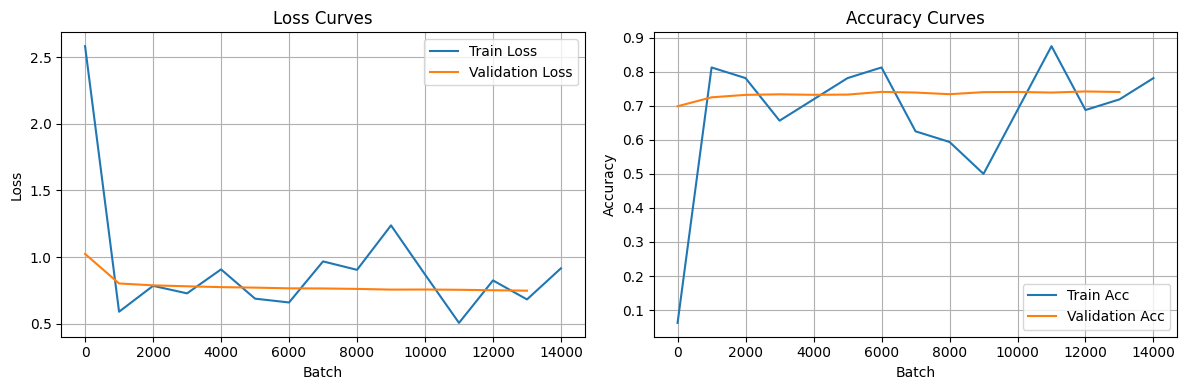

In [27]:
# INSERT_YOUR_REWRITE_HERE

# 1. 使用VGG11.from_pretrained加载预训练模型权重
model = VGG11.from_pretrained1('./checkpoints/cifar10_model_epoch_best.ckpt',num_classes=10)

# 2. 设置参数分组不同学习率
# 因为最后一层名字叫"my_classifier.3"，选择它
last_layer_name = "classifier.3"
param_groups = [
    {"params": [p for n, p in model.named_parameters() if last_layer_name in n], "lr": 1e-3},
    {"params": [p for n, p in model.named_parameters() if last_layer_name not in n], "lr": 1e-5}
]
# print(param_groups)
optimizer_finetune = torch.optim.Adam(param_groups)

# 3. 新Trainer对象（或重用train/val_loader、criterion、device等）
finetune_trainer = wangdao_train.Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer_finetune,
    device=device,
    eval_step=100
)

# 4. 设定微调轮数（如5轮，可以根据需要调整）
finetune_epochs = 10

# 5. 训练&评估
finetune_trainer.train(finetune_epochs)
finetune_trainer.plot_curves()
